# DAY2 — Batch 1 Hold-out 평가

개발 CV에서 선택한 설정을 고정하고 예약 셀 7개를 평가한다. 이 결과로 모델이나 입력 Feature를 다시 선택하지 않는다.

Feature는 ΔQ 분산의 log10 값 하나, Target은 변환하지 않은 전체 수명이다.

In [1]:
from pathlib import Path
import sys
ROOT=next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src/day2_dataset.py').is_file())
sys.path.insert(0,str(ROOT))
import pandas as pd
from IPython.display import display, Image
from src.day2_holdout_evaluation import fit_and_evaluate, SOURCE, save_figures
print('Python:',sys.executable)
frame=pd.read_parquet(ROOT/SOURCE)
model,predictions,metrics=fit_and_evaluate(frame)
save_figures(predictions)
display(pd.Series(metrics,name='평가값'))
display(predictions[['cell_id','actual_life','predicted_life','error_cycles','ape_pct']].round(2))

Python: /Users/soobin/myfolder/workspace/mini-project-data-analysis/.venv/bin/python


model                                       Linear Regression
feature                                      log10_deltaQ_var
target                               untransformed cycle_life
development_n                                              29
holdout_n                                                   7
holdout_mape_pct                                     9.080207
holdout_mae_cycles                                  77.558331
holdout_rmse_cycles                                 91.642839
nonpositive_prediction_n                                    0
development_cv_mean_fold_mape_pct                    8.616772
holdout_minus_cv_mape_pp                             0.463435
holdout_evaluated                                        True
batch2_read_or_evaluated                                False
selection_revisited                                     False
Name: 평가값, dtype: object

,cell_id,actual_life,predicted_life,error_cycles,ape_pct
0,5,1074.0,965.29,-108.71,10.12
1,6,636.0,771.69,135.69,21.33
2,7,870.0,792.75,-77.25,8.88
28,38,617.0,613.11,-3.89,0.63
29,39,625.0,646.86,21.86,3.50
30,40,966.0,906.90,-59.10,6.12
31,41,1051.0,914.59,-136.41,12.98


## 결과 확인

MAPE는 셀별 절대 오차 비율의 평균이다. MAE는 cycle 단위 절대 오차, RMSE는 큰 오차에 더 큰 가중치를 준 cycle 단위 지표다.

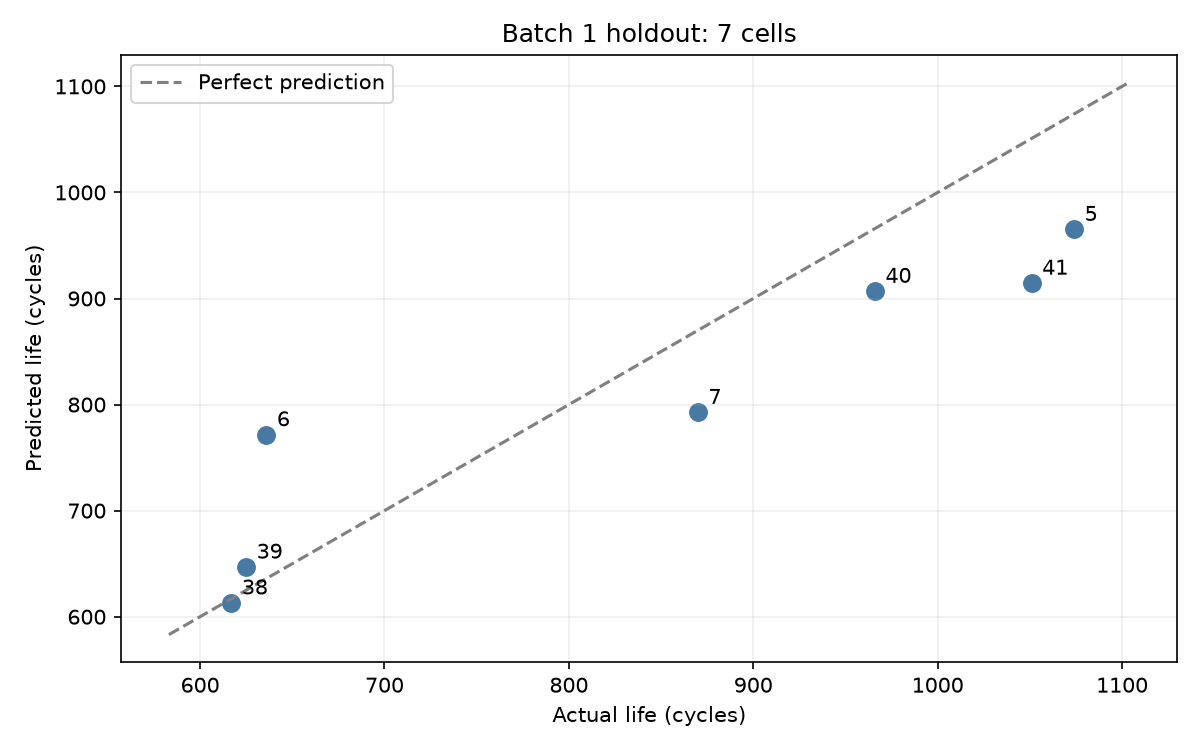

Hold-out MAPE: 9.08%
Development CV 평균: 8.62%
차이: +0.46%p


In [2]:
display(Image(filename=str(ROOT/'outputs/figures/day2/holdout_evaluation/01_holdout_predictions.png')))
print(f"Hold-out MAPE: {metrics['holdout_mape_pct']:.2f}%")
print(f"Development CV 평균: {metrics['development_cv_mean_fold_mape_pct']:.2f}%")
print(f"차이: {metrics['holdout_minus_cv_mape_pp']:+.2f}%p")
assert metrics['holdout_n']==7 and metrics['development_n']==29
assert not metrics['batch2_read_or_evaluated']
assert not metrics['selection_revisited']

Hold-out은 7개여서 오차 차이가 셀 구성에 민감하다. 이번 결과만으로 과적합이나 프로토콜별 일반 성능을 단정하지 않는다. 다음은 고정 설정으로 Batch 1의 유효 36개 전체에 학습하고 Batch 2에서 평가하는 단계다.